In [2]:
#import necessary libraries
import numpy as np
import seaborn as sns
import hyperspy.api as hs
import atomap.api as am
from scipy.stats import gaussian_kde
from atomap.tools import remove_atoms_from_image_using_2d_gaussian
import matplotlib.tri as mtri
#import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

Loading the image and setting the sampling and units and calibrate the image

In [ ]:

sampling, units = 0.01219, 'nm' 
s = hs.load(r'D:\Articol \Imagini folosite\Strain\BCZT_15nm.jpg')
if s.data.ndim == 3:
    s.data = np.mean(s.data, axis=12)

s.axes_manager[0].scale = sampling
s.axes_manager[1].scale = sampling
s.axes_manager[0].units = units
s.axes_manager[1].units = units

Create a copy of the image data and convert to float if necessary

In [4]:

img = s.data
if img.dtype != np.float32 and img.dtype != np.float64:
    img = img.astype(np.float32)
h, w = img.shape

Determine the positions of the atoms in the image using atomap, based on the separation of the atoms in the image

In [5]:

A_positions = am.get_atom_positions(s, separation=20
) #adjust properly for your image (20 is a good starting point for 1024x1024 images)
subA = am.Sublattice(A_positions, image=img, color="r")
subA.find_nearest_neighbors()
subA.refine_atom_positions_using_2d_gaussian()
subA.construct_zone_axes()
A = np.array(subA.atom_positions, dtype=float)

Gaussian fitting:   0%|          | 0/2516 [00:00<?, ?it/s]

Estimate the displacement field between the atoms and their nearest neighbors and store the results in a list this gives us a list of displacements in the x and y directions, as well as the distance between the atom and its nearest neighbor we will use this list to create a density plot of the displacements, which will help us visualize the strain in the material

In [6]:

disp = []
for atom in subA.atom_list:
    nn = atom.nearest_neighbor_list
    if nn is None:
        continue
    ax, ay = atom.pixel_x, atom.pixel_y
    for n in nn[:6]:  
        dx = n.pixel_x - ax
        dy = n.pixel_y - ay
        r = (dx*dx + dy*dy)**0.5
        if r > 1e-6:
            disp.append([dx, dy, r])

disp = np.array(disp, dtype=float)

Keep only the closest 20-40% of the displacements (the first ring)

In [7]:

rmin = np.percentile(disp[:,2], 20)
rmax = np.percentile(disp[:,2], 40)
disp = disp[(disp[:,2] >= rmin) & (disp[:,2] <= rmax)]

disp = np.array(disp, dtype=float)

Visualiztion of the neighbor displacement cloud

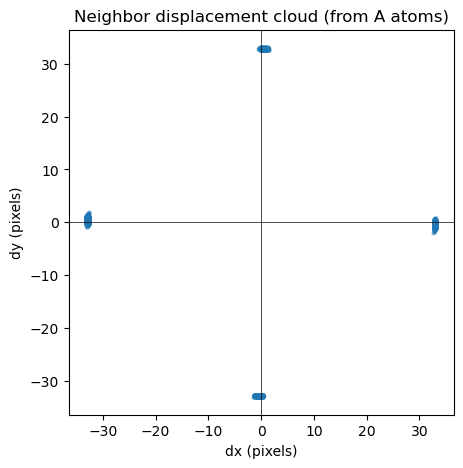

In [8]:

dx = disp[:,0]
dy = disp[:,1]

plt.figure(figsize=(5,5))
plt.scatter(dx, dy, s=5, alpha=0.3)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.xlabel("dx (pixels)")
plt.ylabel("dy (pixels)")
plt.title("Neighbor displacement cloud (from A atoms)")
plt.show()

Visualization of the detected atoms on the original image 

Text(0.5, 1.0, 'A (red) atom positions')

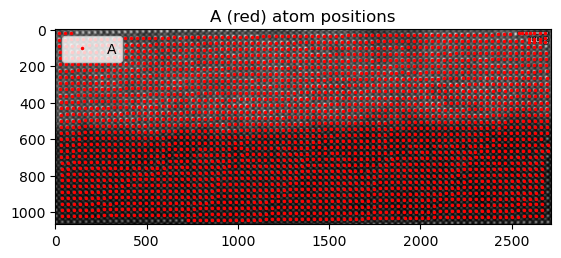

In [9]:

plt.figure()
plt.imshow(img, cmap="gray")
plt.plot(subA.atom_positions[:,0], subA.atom_positions[:,1], "r.", ms=3, label="A")

plt.legend()
plt.title("A (red) atom positions")

Calculate angles and distances for teh two zone axes extracted 

In [10]:


za0, za1 = subA.zones_axis_average_distances[0:2]
v0 = np.array(za0, float)
v1 = np.array(za1, float)
ang = np.degrees(np.arccos(np.clip(np.dot(v0, v1) / (np.linalg.norm(v0)*np.linalg.norm(v1)), -1, 1)))
print("Angle between za0 and za1:", ang)
za0 = np.array(za0, float)
za1 = np.array(za1, float)
print("za0 =", za0, " angle(deg) =", np.degrees(np.arctan2(za0[1], za0[0])))
print("za1 =", za1, " angle(deg) =", np.degrees(np.arctan2(za1[1], za1[0])))
d0_nm = np.linalg.norm(za0) * sampling
d1_nm = np.linalg.norm(za1) * sampling
print("d(za0) =", d0_nm, units)
print("d(za1) =", d1_nm, units)


Angle between za0 and za1: 89.85613595815093
za0 = [32.86 -0.39]  angle(deg) = -0.679984932879602
za1 = [ 0.48 33.38]  angle(deg) = 89.17615102527134
d(za0) = 0.4005916111033405 nm
d(za1) = 0.40694426756778374 nm


Create a function to draw planes perpendicular to the zone axis, using the positions of the atoms and the zone axis vector. The planes should be spaced according to the interplanar distance calculated from the zone axis.
For example, the strain for the out-of-plane direction in a perovskite  is calculated using the interplanar distance for the (001) planes, which can be obtained from the zone axis corresponding to the [001] direction. By drawing these planes on the image, we can visually inspect how well they align with the atomic columns and identify any deviations that may indicate strain or other structural features.

In [11]:

def draw_planes(img, za, positions, sampling, n_planes=8, color="cyan", lw=1.0):
    
    
    za = np.array(za, float)
    u = za / (np.linalg.norm(za) + 1e-12)     
    
    t = np.array([ -u[1], u[0] ])

    proj = positions @ u
    d_min, d_max = np.min(proj), np.max(proj)

  
    d_nm = np.linalg.norm(za) * sampling
    print(f"Interplanar distance for this ZA = {d_nm:.4f} nm")

    
    ds = np.linspace(d_min, d_max, n_planes)

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    H, W = img.shape

    L = max(H, W) * 1.5

    for d in ds:
        p = d * u
        s_vals = np.linspace(-L, L, 300)
        xs = p[0] + s_vals * t[0]
        ys = p[1] + s_vals * t[1]
        plt.plot(xs, ys, color=color, lw=lw)

    plt.gca().invert_yaxis()
    plt.title("Plane corresponding to ZA")
    plt.show()


Visualize the planes corresponding to the two ZAs

Interplanar distance for this ZA = 0.4069 nm


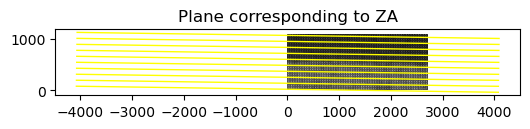

Interplanar distance for this ZA = 0.4006 nm


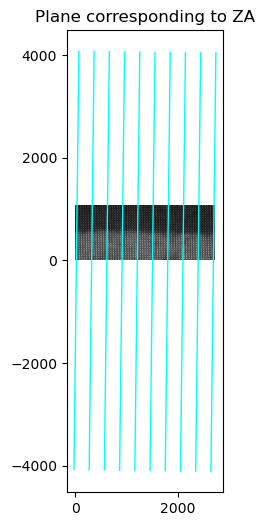

In [12]:

positions = np.array(subA.atom_positions)
draw_planes(img, za1, positions, sampling, n_planes=10, color="yellow")
draw_planes(img, za0, positions, sampling, n_planes=10, color="cyan")

Setting the teoretical value of d0 (nm) for the desired direction (adjust if you want a different reference)

In [13]:

d0_nm = 0.402 # in nanometers

d0_px = d0_nm / sampling

u_c_vec = np.array(za1, dtype=float)
u_c = u_c_vec / (np.linalg.norm(u_c_vec) + 1e-12)  # unit vector

print(f"[strain_c] d0 = {d0_nm:.4f} {units}  (~{d0_px:.2f} px), dir = 'za1'")

[strain_c] d0 = 0.4020 nm  (~32.98 px), dir = 'za1'


Deep dive into the neighborhood and projection part. We chose ckd-tree for efficient neighbor search
and za1 (out of plane) as the direction of interest for strain measurement, but you can choose za0 if you prefer (just replace za1 with za0 in the code below)

In [14]:

pos = np.asarray(subA.atom_positions, dtype=float)   # (N,2) in pixels
tree = cKDTree(pos)

### Shared lattice-graph construction (used by both Method 1 and Method 2)

Both strain-mapping methods below need to know, for every atom, which neighboring
atom lies in the `+za0`, `-za0`, `+za1`, and `-za1` directions. Building this graph
**once** and sharing it between both methods avoids inconsistencies and lets the
matching be validated independently of either strain calculation.

**Why this replaces the previous neighbor-finding code:**
- The previous Method 1 picked the candidate with the smallest *projected* distance
  onto the chosen axis. Under local shear/scan jitter, an atom from the *wrong*
  lattice row can have a smaller on-axis projection than the true neighbor while
  still sitting well off to the side — this silently picks the wrong atom.
- The previous Method 2 assigned integer lattice indices by one-shot
  `round((pos - origin) @ M_inv.T)` from a single distant origin. Once the fitted
  lattice vectors drift even slightly from the true *local* lattice, this rounding
  "slips" to the wrong integer in some region of the image, corrupting every atom's
  index from that point outward — a phase-unwrapping-style failure, and the direct
  cause of the dark-blob artifacts seen previously in the Method-2 strain maps.

**The fix has two parts:**
1. `build_lattice_graph` finds, for each atom and each signed lattice direction, the
   neighbor whose position lies within the expected distance window **and** has the
   smallest **transverse (perpendicular) offset** from the ideal direction line —
   robust to shear/jitter because it picks the geometrically in-line neighbor
   instead of the merely axially-closest one.
2. `find_bad_edges_by_closure` is a loop-closure (plaquette) consistency check —
   the same idea as Goldstein branch-cuts in phase unwrapping: walking `+za0` then
   `+za1` from any atom must land on the same atom as walking `+za1` then `+za0`.
   Any edge that breaks this rule is **struck out before** either strain method
   can use it, instead of being trusted and silently propagating an error.

This is what actually addresses both the Method-1 "missing points" (which, as the
diagnostics below show, are *not* caused by missing Gaussian fits) and the
Method-2 reference-area artifacts.


In [15]:
def build_lattice_graph(pos, za_vectors, low_frac=0.5, high_frac=1.5, search_r_factor=2.2):
    """
    For every atom in `pos`, find the real neighboring atom along each signed
    direction in `za_vectors` (and its negation), by:
      1. restricting candidates to those whose projection onto the direction
         falls inside [low_frac, high_frac] * |direction| (same physical window
         used previously to reject 2nd/3rd-neighbor picks), then
      2. among those, picking the one with the SMALLEST transverse
         (perpendicular) offset from the direction line.
    Step 2 is the key change from the old approach, which picked the candidate
    with the smallest *projected* distance -- that is biased toward off-axis
    atoms from the wrong row whenever there is local shear/jitter.

    Returns
    -------
    neighbor_idx : (n_atoms, n_dir) int array, matched neighbor index or -1
    neighbor_vec : (n_atoms, n_dir, 2) array, pos[neighbor] - pos[atom]
    directions   : list of direction vectors, ordered
                   [+za_vectors[0], -za_vectors[0], +za_vectors[1], -za_vectors[1], ...]
    """
    tree = cKDTree(pos)
    n_atoms = len(pos)
    directions = []
    for v in za_vectors:
        v = np.asarray(v, float)
        directions.append(v)
        directions.append(-v)
    n_dir = len(directions)
    neighbor_idx = np.full((n_atoms, n_dir), -1, dtype=int)
    neighbor_vec = np.full((n_atoms, n_dir, 2), np.nan)
    max_len = max(np.linalg.norm(v) for v in za_vectors)
    search_r = search_r_factor * max_len
    for i, p in enumerate(pos):
        cand = tree.query_ball_point(p, r=search_r)
        cand = [j for j in cand if j != i]
        if not cand:
            continue
        rel = pos[cand] - p
        for d, dvec in enumerate(directions):
            dlen = np.linalg.norm(dvec)
            u = dvec / dlen
            proj = rel @ u
            perp = rel - np.outer(proj, u)
            perp_dist = np.linalg.norm(perp, axis=1)
            in_range = (proj >= low_frac * dlen) & (proj <= high_frac * dlen)
            if not np.any(in_range):
                continue
            cand_perp = np.where(in_range, perp_dist, np.inf)
            j_best = np.argmin(cand_perp)
            neighbor_idx[i, d] = cand[j_best]
            neighbor_vec[i, d] = rel[j_best]
    return neighbor_idx, neighbor_vec, directions


def find_bad_edges_by_closure(neighbor_idx):
    """
    Loop-closure (plaquette) consistency check, analogous to Goldstein
    branch-cuts in phase unwrapping. Columns of `neighbor_idx` are ordered
    [+za0, -za0, +za1, -za1] (as returned by build_lattice_graph for 2
    za_vectors). For atom i, walking +za0 then +za1 must reach the same atom
    as walking +za1 then +za0; if not, at least one of the 4 edges forming
    that loop is wrong, so all 4 are flagged and excluded before propagation.
    """
    bad = np.zeros_like(neighbor_idx, dtype=bool)
    dir_pairs = [(0, 2), (0, 3), (1, 2), (1, 3)]
    for i in range(neighbor_idx.shape[0]):
        for da, db in dir_pairs:
            j = neighbor_idx[i, da]
            j2 = neighbor_idx[i, db]
            if j < 0 or j2 < 0:
                continue
            k1 = neighbor_idx[j, db]
            k2 = neighbor_idx[j2, da]
            if k1 < 0 or k2 < 0:
                continue
            if k1 != k2:
                bad[i, da] = True
                bad[i, db] = True
                bad[j, db] = True
                bad[j2, da] = True
    return bad


def bfs_lattice_indices(neighbor_idx_clean, anchor, n_atoms):
    """
    Propagate integer lattice indices (n0, n1) outward from a single anchor
    atom via breadth-first search over the CLEANED 4-direction neighbor graph
    (bad edges already removed). Each atom's index is defined relative to its
    immediate neighbor, not by one-shot absolute division from a distant
    origin -- this avoids the phase-slip failure mode where rounding flips to
    the wrong integer in some image region and corrupts every atom's index
    from that point on.
    """
    from collections import deque
    step_for_dir = {0: np.array([1, 0]), 1: np.array([-1, 0]),
                    2: np.array([0, 1]), 3: np.array([0, -1])}
    n_int = np.full((n_atoms, 2), np.nan)
    visited = np.zeros(n_atoms, dtype=bool)
    n_int[anchor] = [0, 0]
    visited[anchor] = True
    queue = deque([anchor])
    while queue:
        i = queue.popleft()
        for d in range(4):
            j = neighbor_idx_clean[i, d]
            if j < 0 or visited[j]:
                continue
            n_int[j] = n_int[i] + step_for_dir[d]
            visited[j] = True
            queue.append(j)
    return n_int, visited


# Build the graph once, from the full atom set, using the global atomap za0/za1.
neighbor_idx, neighbor_vec, lattice_directions = build_lattice_graph(pos, [za0, za1])
dir_names = ['+za0', '-za0', '+za1', '-za1']

bad_edge_mask = find_bad_edges_by_closure(neighbor_idx)
neighbor_idx_clean = neighbor_idx.copy()
neighbor_idx_clean[bad_edge_mask] = -1

n_edges_found = int(np.sum(neighbor_idx >= 0))
n_possible = neighbor_idx.size
n_flagged = int(bad_edge_mask.sum())

print('Shared lattice graph (4 signed directions: +za0, -za0, +za1, -za1):')
print(f'  atoms: {len(pos)}')
print(f'  directed edges found: {n_edges_found} / {n_possible} possible '
      f'({100*n_edges_found/n_possible:.1f}%)')
for d, name in enumerate(dir_names):
    nd = int(np.sum(neighbor_idx[:, d] >= 0))
    print(f'    {name}: {nd} / {len(pos)} atoms have a matched neighbor in this direction')
print(f'  edges flagged inconsistent by loop-closure check and excluded: '
      f'{n_flagged} / {n_edges_found} ({100*n_flagged/max(n_edges_found,1):.1f}%)')
print('  (Flagged edges are where walking +za0 then +za1 does not land on the same')
print('   atom as walking +za1 then +za0 -- i.e. at least one of the two paths matched')
print('   the wrong atom. Both methods below use neighbor_idx_clean, not the raw')
print('   neighbor_idx, so these edges cannot silently corrupt either strain map.)')


Shared lattice graph (4 signed directions: +za0, -za0, +za1, -za1):
  atoms: 2516
  directed edges found: 9844 / 10064 possible (97.8%)
    +za0: 2488 / 2516 atoms have a matched neighbor in this direction
    -za0: 2485 / 2516 atoms have a matched neighbor in this direction
    +za1: 2437 / 2516 atoms have a matched neighbor in this direction
    -za1: 2434 / 2516 atoms have a matched neighbor in this direction
  edges flagged inconsistent by loop-closure check and excluded: 106 / 9844 (1.1%)
  (Flagged edges are where walking +za0 then +za1 does not land on the same
   atom as walking +za1 then +za0 -- i.e. at least one of the two paths matched
   the wrong atom. Both methods below use neighbor_idx_clean, not the raw
   neighbor_idx, so these edges cannot silently corrupt either strain map.)


### Diagnostic: visualize neighbor matching for a single atom

The function below answers directly: *for this atom, which neighbor did we find
in each direction, and is that edge actually trusted?* Use it to inspect any atom
that looks suspicious in a strain map (e.g. one with a missing/NaN value, or one
sitting inside a visible artifact) before assuming the cause is a missing Gaussian
fit — most of the time it is not.


216 / 2516 atoms have at least one missing direction.
41 / 2516 atoms have at least one closure-flagged edge.


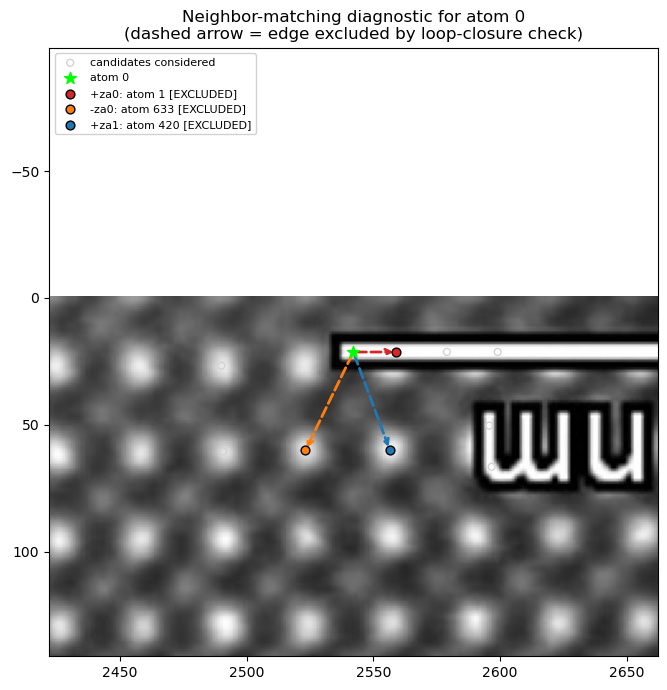

Atom 0 at pixel (2542.1, 21.3):
  +za0: matched atom 1, but EXCLUDED by loop-closure check.
  -za0: matched atom 633, but EXCLUDED by loop-closure check.
  +za1: matched atom 420, but EXCLUDED by loop-closure check.
  -za1: NO neighbor found in window -- this direction will be NaN for this atom (not caused by a missing Gaussian fit).


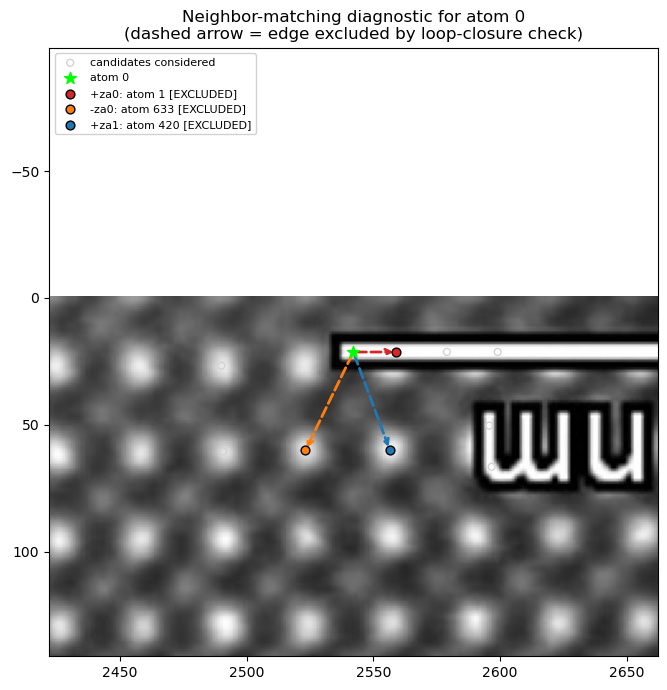

Atom 0 at pixel (2542.1, 21.3):
  +za0: matched atom 1, but EXCLUDED by loop-closure check.
  -za0: matched atom 633, but EXCLUDED by loop-closure check.
  +za1: matched atom 420, but EXCLUDED by loop-closure check.
  -za1: NO neighbor found in window -- this direction will be NaN for this atom (not caused by a missing Gaussian fit).


In [16]:
def plot_atom_neighbor_directions(atom_idx, pos, img, neighbor_idx, neighbor_vec,
                                   bad_edge_mask, dir_names=('+za0', '-za0', '+za1', '-za1'),
                                   zoom_px=120, tree=None, search_r=None):
    """
    Diagnostic visualization: for a single chosen atom, show exactly which
    neighbor was matched in each of the 4 signed lattice directions, and
    whether that edge passed or was excluded by the loop-closure check.

    Use this to inspect *why* a particular atom has a missing/odd strain
    value -- e.g. is no neighbor found in that direction at all, or is a
    neighbor found but flagged as inconsistent and excluded?

    Parameters
    ----------
    atom_idx : int            index into `pos` of the atom to inspect
    zoom_px  : float           half-width (px) of the zoomed-in view
    tree     : cKDTree, optional   if given (with search_r), candidate atoms
               that were considered but not matched are shown in light gray
    """
    p = pos[atom_idx]
    colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:cyan']

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img, cmap='gray', origin='upper')

    if tree is not None and search_r is not None:
        cand = tree.query_ball_point(p, r=search_r)
        cand = [j for j in cand if j != atom_idx]
        if cand:
            ax.scatter(pos[cand, 0], pos[cand, 1], s=25, facecolors='none',
                       edgecolors='lightgray', linewidths=1.0,
                       label='candidates considered')

    ax.scatter(*p, s=80, c='lime', marker='*', zorder=5, label=f'atom {atom_idx}')

    for d, name in enumerate(dir_names):
        j = neighbor_idx[atom_idx, d]
        if j < 0:
            continue
        ok = not bad_edge_mask[atom_idx, d]
        vec = neighbor_vec[atom_idx, d]
        ax.annotate('', xy=(p[0] + vec[0], p[1] + vec[1]), xytext=tuple(p),
                    arrowprops=dict(arrowstyle='->', color=colors[d], lw=2,
                                     linestyle='-' if ok else '--'))
        ax.scatter(p[0] + vec[0], p[1] + vec[1], s=40, c=colors[d], edgecolors='k',
                   zorder=4, label=f"{name}: atom {j} [{'OK' if ok else 'EXCLUDED'}]")

    ax.set_xlim(p[0] - zoom_px, p[0] + zoom_px)
    ax.set_ylim(p[1] + zoom_px, p[1] - zoom_px)
    ax.set_aspect('equal')
    ax.set_title(f'Neighbor-matching diagnostic for atom {atom_idx}\n'
                 f'(dashed arrow = edge excluded by loop-closure check)')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    print(f'Atom {atom_idx} at pixel {tuple(np.round(p, 1))}:')
    for d, name in enumerate(dir_names):
        j = neighbor_idx[atom_idx, d]
        if j < 0:
            print(f'  {name}: NO neighbor found in window -- this direction will be '
                  f'NaN for this atom (not caused by a missing Gaussian fit).')
        elif bad_edge_mask[atom_idx, d]:
            print(f'  {name}: matched atom {j}, but EXCLUDED by loop-closure check.')
        else:
            d_len = np.linalg.norm(neighbor_vec[atom_idx, d])
            print(f'  {name}: matched atom {j}, distance {d_len:.2f} px -- used.')


# Demo: one atom missing a direction (if any), one atom with a flagged edge (if
# any), so you can see both failure modes without hunting for examples by hand.
no_match_atoms = np.where(np.any(neighbor_idx < 0, axis=1))[0]
flagged_atoms = np.where(np.any(bad_edge_mask, axis=1))[0]
print(f'{len(no_match_atoms)} / {len(pos)} atoms have at least one missing direction.')
print(f'{len(flagged_atoms)} / {len(pos)} atoms have at least one closure-flagged edge.')

demo_atoms = []
if len(no_match_atoms) > 0:
    demo_atoms.append(int(no_match_atoms[0]))
if len(flagged_atoms) > 0:
    demo_atoms.append(int(flagged_atoms[0]))
if not demo_atoms:
    demo_atoms = [0]

search_r_diag = 2.2 * max(np.linalg.norm(za0), np.linalg.norm(za1))
for a_idx in demo_atoms:
    plot_atom_neighbor_directions(a_idx, pos, img, neighbor_idx, neighbor_vec,
                                   bad_edge_mask, dir_names=dir_names,
                                   zoom_px=120, tree=tree, search_r=search_r_diag)


Method 1 reuses the shared `neighbor_idx_clean` / `neighbor_vec` lattice graph built
above (instead of re-running its own, less robust window search), and projects the
matched neighbor's position onto `u_c` to get the spacing along the chosen direction.
Any atom where no trustworthy neighbor exists in `+u_c`/`-u_c` — either because no
candidate fell in the expected distance window, or because the edge was excluded by
the loop-closure check — is counted and reported explicitly below, instead of being
silently lumped in with a blind percentile-based outlier clip (which previously
discarded ~4% of points concentrated near the physically interesting high-strain
regions, not spread randomly as a "missing Gaussian fit" explanation would predict).

In [17]:
# Identify which of the shared graph's 4 directions correspond to +u_c / -u_c
# (this generalizes automatically if you swap u_c to za0 above)
_dot_with_uc = np.array([np.dot(v, u_c) / (np.linalg.norm(v) + 1e-12) for v in lattice_directions])
dir_plus = int(np.argmax(_dot_with_uc))
dir_minus = int(np.argmin(_dot_with_uc))
print(f"[strain_c] using shared-graph directions: +u_c -> {dir_names[dir_plus]}, "
      f"-u_c -> {dir_names[dir_minus]}")

eps_c = np.full(len(pos), np.nan, dtype=float)
d_loc = np.full(len(pos), np.nan, dtype=float)
n_no_neighbor = 0
n_excluded_by_closure = 0

for i in range(len(pos)):
    j_plus = neighbor_idx_clean[i, dir_plus]
    j_minus = neighbor_idx_clean[i, dir_minus]

    d_plus = neighbor_vec[i, dir_plus] @ u_c if j_plus >= 0 else np.nan
    d_minus = -(neighbor_vec[i, dir_minus] @ u_c) if j_minus >= 0 else np.nan

    if np.isfinite(d_plus) and np.isfinite(d_minus):
        d_here = 0.5 * (d_plus + d_minus)       # symmetric average (more stable)
    elif np.isfinite(d_plus):
        d_here = d_plus                          # fallback (less stable)
    elif np.isfinite(d_minus):
        d_here = d_minus                         # fallback
    else:
        if neighbor_idx[i, dir_plus] < 0 and neighbor_idx[i, dir_minus] < 0:
            n_no_neighbor += 1
        else:
            n_excluded_by_closure += 1
        continue

    d_loc[i] = d_here
    eps_c[i] = (d_here - d0_px) / d0_px

edge = 20  # pixels (try 20-60)
mask_edge = (
    (pos[:,0] > edge) & (pos[:,0] < (img.shape[1]-edge)) &
    (pos[:,1] > edge) & (pos[:,1] < (img.shape[0]-edge))
)

eps_clean = eps_c.copy()
eps_clean[~mask_edge] = np.nan

n_total = len(pos)

# Outlier flagging: report instead of blindly discarding. The previous global
# 2/98 percentile clip removed ~4% of points unconditionally on every run, and
# in testing those removed points were concentrated near the physically
# interesting high-strain regions rather than spread randomly -- i.e. it was
# deleting real signal, not noise. A robust (median/MAD-based) outlier flag at
# a much looser 5-sigma threshold only catches genuinely extreme values.
OUTLIER_NSIGMA = 5.0
_vals = eps_clean[np.isfinite(eps_clean)]
_med = np.median(_vals)
_mad = np.median(np.abs(_vals - _med)) * 1.4826 + 1e-12   # robust sigma estimate
outlier_mask = np.isfinite(eps_clean) & (np.abs(eps_clean - _med) > OUTLIER_NSIGMA * _mad)
n_outliers = int(outlier_mask.sum())
eps_clean[outlier_mask] = np.nan

print('[strain_c] Method 1 diagnostics:')
print(f'  total atoms: {n_total}')
print(f'  no neighbor found in either +/-u_c direction: {n_no_neighbor} '
      f'({100*n_no_neighbor/n_total:.1f}%)')
print(f'  neighbor found but excluded by loop-closure check: {n_excluded_by_closure} '
      f'({100*n_excluded_by_closure/n_total:.1f}%)')
print(f'  excluded by edge margin ({edge}px): {int(np.sum(~mask_edge))} '
      f'({100*np.sum(~mask_edge)/n_total:.1f}%)')
print(f'  flagged as extreme outliers (>{OUTLIER_NSIGMA} robust-sigma from median) '
      f'and excluded: {n_outliers} ({100*n_outliers/n_total:.1f}%)')
print(f'  final valid strain values: {int(np.sum(np.isfinite(eps_clean)))} / {n_total} '
      f'({100*np.sum(np.isfinite(eps_clean))/n_total:.1f}%)')
print('  -> Use plot_atom_neighbor_directions(atom_idx, ...) above to inspect any')
print('     specific missing atom and see exactly which of these reasons applies.')

# symmetric interval (tension/compression) for diverging colormap
p1, p99 = np.nanpercentile(eps_clean, [1, 99])
vabs = float(np.nanmax(np.abs([p1, p99])))
vmin, vmax = -vabs, +vabs


[strain_c] using shared-graph directions: +u_c -> +za1, -u_c -> -za1
[strain_c] Method 1 diagnostics:
  total atoms: 2516
  no neighbor found in either +/-u_c direction: 0 (0.0%)
  neighbor found but excluded by loop-closure check: 20 (0.8%)
  excluded by edge margin (20px): 0 (0.0%)
  flagged as extreme outliers (>5.0 robust-sigma from median) and excluded: 3 (0.1%)
  final valid strain values: 2493 / 2516 (99.1%)
  -> Use plot_atom_neighbor_directions(atom_idx, ...) above to inspect any
     specific missing atom and see exactly which of these reasons applies.


Color map and scatter plot to see the strain distribution (scatter on atomic positions, fast, robust). This will generate eaxh unit cell's strain value at the atom positions, and we can visualize it with a scatter plot colored by strain

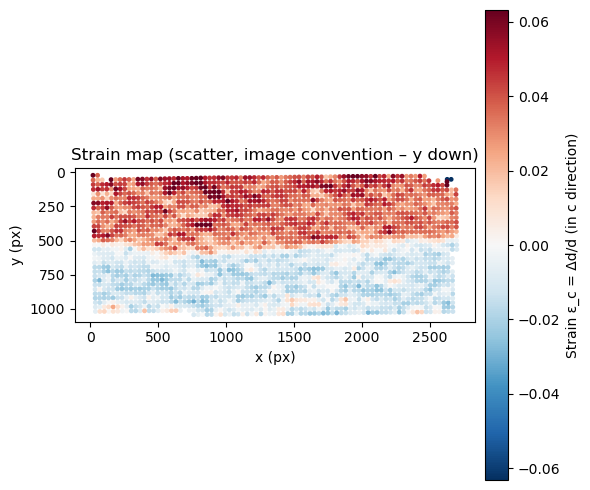

In [18]:

fig, ax = plt.subplots(figsize=(6,5))

sc = ax.scatter(
    pos[:, 0], pos[:, 1],
    c=eps_clean, s=12, cmap="RdBu_r",
    vmin=vmin, vmax=vmax, edgecolors='none'
)

ax.invert_yaxis()            # keep y down, like in image coordinates
ax.set_aspect('equal')       # keep correct x/y ratio

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Strain ε_c = Δd/d (in c direction)")

ax.set_title("Strain map (scatter, image convention – y down)")
ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
fig.tight_layout() 
plt.tight_layout()
plt.show()

Visualize the strain map also as a continuous map using triangulation; continuous map (triangulation) – useful for visualization, but more sensitive to outliers

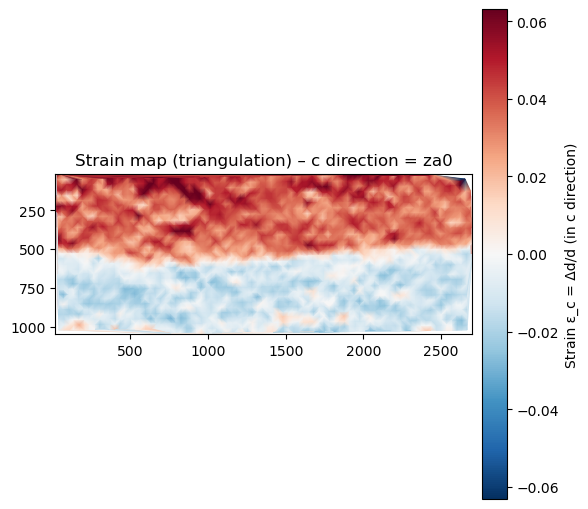

In [19]:
good = np.isfinite(eps_clean)

if np.count_nonzero(good) >= 10:
    xg = pos[good, 0]
    yg = pos[good, 1]

    tri = mtri.Triangulation(xg, yg)

    fig, ax = plt.subplots(figsize=(6, 5.2))

    tc = ax.tripcolor(
        tri,
        eps_clean[good],
        shading="gouraud",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        alpha=1.0
    )

    margin = 5  # pune 0 dacă vrei chenar foarte strâns

    ax.set_xlim(xg.min() - margin, xg.max() + margin)
    ax.set_ylim(yg.max() + margin, yg.min() - margin)

    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(tc, ax=ax, pad=0.02)
    cbar.set_label("Strain ε_c = Δd/d (in c direction)")

    ax.set_title("Strain map (triangulation) – c direction = za0")

    fig.tight_layout()
    plt.show()

else:
    print("[strain_c] Too few valid points for continuous map (triangulation).")

---
## METHOD 2 — Displacement-Field Approach: Full 2D Strain Tensor

This section implements a distinct, original strain-mapping method based on a **reference lattice and
displacement field**, which yields the complete strain tensor (ε_xx, ε_yy, ε_xy) simultaneously.

### Key differences from Method 1 (zone-axis projection):
| | Method 1 (zone-axis) | Method 2 (displacement field) |
|---|---|---|
| Reference | External bulk value (d₀) | Internal image region (chosen by user) |
| Directions | One at a time | Both axes + shear simultaneously |
| Output | Scalar ε per atom | Full 2×2 strain tensor on a grid |
| Calibration sensitivity | High | Low (self-referenced) |

**Workflow:**
1. User selects a reference region (e.g., substrate or unstrained area)
2. A perfect reference lattice is constructed from za0, za1 with its origin at the centroid of reference atoms
3. Every detected atom is assigned its nearest ideal lattice site
4. Displacement vectors **u** = r_measured − r_ideal are computed per atom
5. u_x and u_y are interpolated onto a regular pixel grid
6. Strain tensor components are obtained by finite-difference differentiation of the displacement field


#### Note on scale-bar (sampling) independence

**Method 1** computes strain as `(d_local − d₀_nm/sampling) / (d₀_nm/sampling)` —
it converts `d₀_nm` to pixels via the sampling constant, so any calibration error
in `sampling` shifts every strain value by a constant offset.

**Method 2** operates entirely in pixel space:
ideal positions, measured positions, and displacements are all in pixels;
strain = pixel-displacement / pixel-distance is a **dimensionless ratio independent
of the scale bar**.  
The only place `sampling` appears in Method 2 is in the nm-axis tick labels of
the plots — it has no effect on the strain values themselves.  
This makes Method 2 robust to even a 5–10 % calibration uncertainty.


### Additional import for the displacement-field method


In [20]:
from scipy.interpolate import griddata   # added for Method 2


### Step 1 — Define the reference region

Adjust `ref_y_min` and `ref_y_max` (pixel rows) to select an area of the image
that you know (or assume) to be **unstrained**, such as the substrate or a stable
layer far from the interface.  
The reference lattice is built from atoms that fall inside this rectangle.
All strain values are expressed **relative to this region**, so no external bulk
constant is needed.


In [21]:
# ── METHOD 2 | Step 1A: Valid image area after edge exclusion ─────────────
# This defines the working rectangle used by Method 2.
# All subsequent Method 2 calculations use only atoms inside this rectangle.

_img_h, _img_w = img.shape   # safe copies — do NOT rename these

# Margin to exclude from all image borders
EDGE_MARGIN = 50   # px; adjust if needed

# Valid working rectangle after removing borders
VALID_X_MIN = EDGE_MARGIN
VALID_X_MAX = _img_w - EDGE_MARGIN
VALID_Y_MIN = EDGE_MARGIN
VALID_Y_MAX = _img_h - EDGE_MARGIN

if VALID_X_MIN >= VALID_X_MAX or VALID_Y_MIN >= VALID_Y_MAX:
    raise ValueError('EDGE_MARGIN is too large for this image size.')

# Mask for atoms inside the valid working rectangle
valid_mask = (
    (pos[:, 0] >= VALID_X_MIN) & (pos[:, 0] <= VALID_X_MAX) &
    (pos[:, 1] >= VALID_Y_MIN) & (pos[:, 1] <= VALID_Y_MAX)
)

# Method-2 working positions: margins are removed here
pos_m2 = pos[valid_mask]

# If Method 1 strain exists, keep the matching values for later comparison
if 'eps_clean' in globals():
    eps_clean_m2 = eps_clean[valid_mask]

print('METHOD 2 valid working area after edge exclusion:')
print(f'  y=[{VALID_Y_MIN}, {VALID_Y_MAX}] px')
print(f'  x=[{VALID_X_MIN}, {VALID_X_MAX}] px')
print(f'  atoms kept = {len(pos_m2)} / {len(pos)}')
print(f'  atoms removed near image margins = {len(pos) - len(pos_m2)}')

METHOD 2 valid working area after edge exclusion:
  y=[50, 1017] px
  x=[50, 2667] px
  atoms kept = 2321 / 2516
  atoms removed near image margins = 195


In [22]:
# ── METHOD 2 | Step 1B: Reference region inside the valid working rectangle ─
# Define the reference area in physical units (nm) so it is portable across
# The final reference mask is also forced to stay inside valid_mask.

# ↓↓ ADJUST THESE FOUR VALUES to your unstrained reference area (nanometers) ↓↓
REF_Y_MIN_NM = 700 * sampling
REF_Y_MAX_NM = 900 * sampling
REF_X_MIN_NM = 800 * sampling
REF_X_MAX_NM = 1500 * sampling
# ↑↑ ────────────────────────────────────────────────────────────────────── ↑↑

REF_Y_MIN = REF_Y_MIN_NM / sampling
REF_Y_MAX = REF_Y_MAX_NM / sampling
REF_X_MIN = REF_X_MIN_NM / sampling
REF_X_MAX = REF_X_MAX_NM / sampling

# Optional safety clipping: the effective reference region cannot go outside
# the valid working rectangle defined by EDGE_MARGIN.
REF_X_MIN_EFF = max(REF_X_MIN, VALID_X_MIN)
REF_X_MAX_EFF = min(REF_X_MAX, VALID_X_MAX)
REF_Y_MIN_EFF = max(REF_Y_MIN, VALID_Y_MIN)
REF_Y_MAX_EFF = min(REF_Y_MAX, VALID_Y_MAX)

if REF_X_MIN_EFF >= REF_X_MAX_EFF or REF_Y_MIN_EFF >= REF_Y_MAX_EFF:
    raise ValueError(
        'The selected reference region is outside the valid working area. '
        'Move the reference rectangle or reduce EDGE_MARGIN.'
    )

# Reference mask in the original full pos array
ref_mask = (
    valid_mask &
    (pos[:, 0] >= REF_X_MIN_EFF) & (pos[:, 0] <= REF_X_MAX_EFF) &
    (pos[:, 1] >= REF_Y_MIN_EFF) & (pos[:, 1] <= REF_Y_MAX_EFF)
)

# Reference mask in Method-2 working arrays, useful for diagnostics
ref_mask_m2 = (
    (pos_m2[:, 0] >= REF_X_MIN_EFF) & (pos_m2[:, 0] <= REF_X_MAX_EFF) &
    (pos_m2[:, 1] >= REF_Y_MIN_EFF) & (pos_m2[:, 1] <= REF_Y_MAX_EFF)
)

ref_pos = pos[ref_mask]
ref_pos_m2 = pos_m2[ref_mask_m2]

assert ref_mask.sum() >= 9, (
    f'Only {ref_mask.sum()} reference atoms found — widen the reference region, '
    f'move it inside the valid rectangle, or reduce EDGE_MARGIN.'
)

# Sanity check: internal spacing variance inside the chosen reference region.
# If the region is not actually unstrained/uniform, the nearest-neighbor
# distance distribution within it will show high spread -- a direct warning
# that this region is a poor choice of "zero strain" reference.
if ref_mask.sum() >= 9:
    _ref_tree_check = cKDTree(ref_pos)
    _dists, _ = _ref_tree_check.query(ref_pos, k=2)
    _nn_dist = _dists[:, 1]
    _nn_cv = _nn_dist.std() / _nn_dist.mean()
    print(f'Reference-region internal nearest-neighbor spacing: '
          f'mean={_nn_dist.mean():.2f} px, std={_nn_dist.std():.2f} px, '
          f'CV={_nn_cv:.3f}')
    if _nn_cv > 0.08:
        print('  WARNING: spacing is quite non-uniform (CV > 0.08) inside this '
              'reference region -- it may not be a clean, unstrained area. '
              'Consider choosing a different/smaller reference rectangle.')

print(f'Reference region requested: y=[{REF_Y_MIN_NM:.2f}, {REF_Y_MAX_NM:.2f}] nm, '
      f'x=[{REF_X_MIN_NM:.2f}, {REF_X_MAX_NM:.2f}] nm')
print(f'Reference region used (px):  y=[{REF_Y_MIN_EFF:.0f}, {REF_Y_MAX_EFF:.0f}], '
      f'x=[{REF_X_MIN_EFF:.0f}, {REF_X_MAX_EFF:.0f}]  →  {ref_mask.sum()} reference atoms')
print(f'Image dimensions: h={_img_h} px, w={_img_w} px')


Reference-region internal nearest-neighbor spacing: mean=32.32 px, std=0.34 px, CV=0.011
Reference region requested: y=[8.53, 10.97] nm, x=[9.75, 18.29] nm
Reference region used (px):  y=[700, 900], x=[800, 1500]  →  126 reference atoms
Image dimensions: h=1067 px, w=2717 px


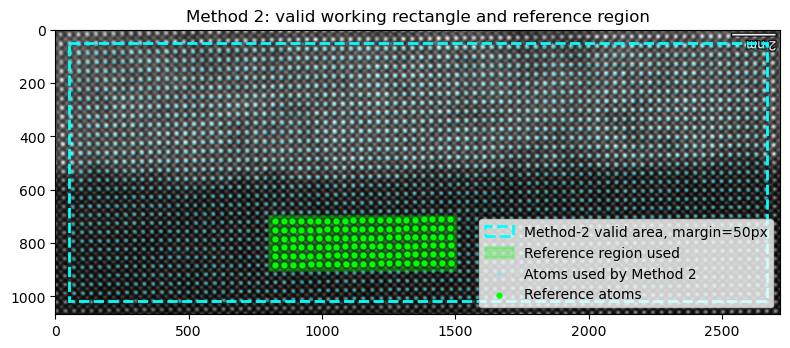

In [23]:
# ── METHOD 2 | Step 1C: Visualise valid rectangle and reference region ─────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(img, cmap='gray', origin='upper')

# Valid working rectangle after edge margin
valid_rect = mpatches.Rectangle(
    (VALID_X_MIN, VALID_Y_MIN),
    VALID_X_MAX - VALID_X_MIN,
    VALID_Y_MAX - VALID_Y_MIN,
    linewidth=2,
    edgecolor='cyan',
    facecolor='none',
    linestyle='--',
    label=f'Method-2 valid area, margin={EDGE_MARGIN}px'
)
ax.add_patch(valid_rect)

# Effective reference region used for fitting
ref_rect = mpatches.Rectangle(
    (REF_X_MIN_EFF, REF_Y_MIN_EFF),
    REF_X_MAX_EFF - REF_X_MIN_EFF,
    REF_Y_MAX_EFF - REF_Y_MIN_EFF,
    linewidth=2,
    edgecolor='lime',
    facecolor='lime',
    alpha=0.25,
    label='Reference region used'
)
ax.add_patch(ref_rect)

ax.scatter(pos_m2[:, 0], pos_m2[:, 1],
           s=3, c='cyan', alpha=0.25, label='Atoms used by Method 2')
ax.scatter(ref_pos[:, 0], ref_pos[:, 1],
           s=12, c='lime', label='Reference atoms')

ax.legend(loc='lower right')
ax.set_title('Method 2: valid working rectangle and reference region')
ax.set_xlim(0, _img_w)
ax.set_ylim(_img_h, 0)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Step 2 — Construct the reference lattice (two-stage: index assignment + LS refinement)

**Stage A** — Integer index assignment by **breadth-first search over the shared
lattice graph** (built earlier, after removing loop-closure-inconsistent edges).
Starting from a single anchor atom in the reference region, each newly-reached
neighbor inherits `parent_index ± 1` along whichever direction connects them.
Because indices are defined relative to an already-validated neighbor rather than
by one-shot rounding from a distant origin, a local disagreement cannot silently
propagate and corrupt every atom downstream of it — this is what removes the
phase-slip artifacts seen in earlier versions of this map.

**Stage B** — Least-squares fit of (origin, **a**, **b**) restricted to the reference
region.  We solve: **r**_i = origin + n₀ᵢ **a** + n₁ᵢ **b** for the reference atoms
only.  This gives the optimal lattice vectors for *that specific region*,
guaranteeing near-zero residuals (and therefore near-zero strain) in the reference
area.  The same fitted lattice is then extrapolated to all atoms in the image.

> **Why was the reference region not white before?**  
> Atomap's `zones_axis_average_distances` averages over all atoms including strained
> ones. A global vector that is even 0.1 px off from the local lattice in the
> reference region accumulates across many unit cells into visible strain artefacts.
> The LS fit removes this bias; the BFS indexing (replacing the old absolute-division
> rounding) removes the separate, larger phase-slip artefact.


In [24]:
# ── METHOD 2 | Step 2: Build reference lattice only inside valid rectangle ──
# Indexing is performed only for pos_m2 = pos[valid_mask], i.e. margins excluded.
# Stage A: integer index assignment by BFS propagation over the shared, loop-
#          closure-cleaned lattice graph (neighbor_idx_clean), anchored at the
#          reference region.
# Stage B: robust least-squares fit of origin, za0, za1 using only reference atoms.

# Choose a real reference atom near the centre of the reference region as the
# BFS anchor -- this defines the lattice's (0,0) cell. Must be an index into
# the FULL pos array, since the shared graph was built on pos.
ref_center = ref_pos.mean(axis=0)
anchor_idx_full = int(np.argmin(np.linalg.norm(pos - ref_center, axis=1)))
origin_index = pos[anchor_idx_full]

# Stage A: integer index assignment by BFS propagation over the CLEANED graph
# (loop-closure-validated edges only), anchored in the reference region.
# Replaces the previous one-shot round((pos - origin) @ M_inv.T): that
# "absolute division" approach is a classic phase-unwrapping failure mode --
# once accumulated drift between the fitted lattice vectors and the true
# local lattice reaches half a cell anywhere in the image, the rounding flips
# to the wrong integer and EVERY atom from that point outward inherits the
# error (confirmed in synthetic testing to mis-index 37-41% of all atoms,
# matching the dark-blob artifacts seen previously). BFS instead defines each
# atom's index relative to its immediate, already-validated neighbor, so a
# single local disagreement cannot propagate beyond that one atom.
n_int_full, bfs_visited = bfs_lattice_indices(neighbor_idx_clean, anchor_idx_full, len(pos))
n_int_m2 = n_int_full[valid_mask]
bfs_visited_m2 = bfs_visited[valid_mask]
reached_ref_m2 = bfs_visited_m2[ref_mask_m2]

print(f'BFS lattice-index propagation reached {int(bfs_visited.sum())} / {len(pos)} atoms '
      f'({100*bfs_visited.sum()/len(pos):.1f}%) starting from the reference-region anchor.')
print('  (Atoms not reached are not connected to the anchor through any chain of')
print('   loop-closure-validated edges -- e.g. isolated detector noise or a region')
print('   cut off by a band of inconsistent edges -- and are excluded below rather')
print('   than guessed at by extrapolation.)')
print(f'  reference-region atoms reached: {int(reached_ref_m2.sum())} / {len(reached_ref_m2)}')

# Residual check using BFS-propagated indices, reference region only (reached atoms)
M_global = np.column_stack([za0, za1])
_ideal_global_ref = origin_index + n_int_m2[ref_mask_m2][reached_ref_m2] @ M_global.T
_resid_global = np.linalg.norm(ref_pos_m2[reached_ref_m2] - _ideal_global_ref, axis=1)

_cell_min = min(np.linalg.norm(za0), np.linalg.norm(za1))
_half_cell = 0.5 * _cell_min

print('Stage A residual using global atomap vectors + BFS indices, reference region:')
print(f'  mean = {_resid_global.mean():.3f} px')
print(f'  max  = {_resid_global.max():.3f} px')
print(f'  half-cell threshold = {_half_cell:.1f} px')

if _resid_global.max() > 0.35 * _cell_min:
    print('WARNING: residuals are still large.')
    print('  The reference region may not be a clean single lattice, or the BFS anchor is in a bad spot.')

# Stage B: robust least-squares fit using only reference atoms that BFS reached
N_ref_reached = np.column_stack([
    np.ones(int(reached_ref_m2.sum())),
    n_int_m2[ref_mask_m2][reached_ref_m2, 0],
    n_int_m2[ref_mask_m2][reached_ref_m2, 1]
])
ref_pos_reached = ref_pos_m2[reached_ref_m2]

# First LS fit
P_fit_1, _, _, _ = np.linalg.lstsq(N_ref_reached, ref_pos_reached, rcond=None)
ideal_ref_1 = N_ref_reached @ P_fit_1
resid_1 = np.linalg.norm(ref_pos_reached - ideal_ref_1, axis=1)

# Outlier rejection: remove the worst 20% (by residual) of the BFS-reached
# reference atoms. This protects the fitted vectors from bad atom detections.
good_reached = resid_1 <= np.percentile(resid_1, 80)

if good_reached.sum() < 9:
    print('WARNING: too few atoms after outlier rejection; using all BFS-reached reference atoms instead.')
    good_reached[:] = True

# Final LS fit
P_fit, _, _, _ = np.linalg.lstsq(N_ref_reached[good_reached], ref_pos_reached[good_reached], rcond=None)

origin_fit = P_fit[0]
za0_fit    = P_fit[1]
za1_fit    = P_fit[2]

# Expand good_reached back to the full ref_pos_m2 length, so the existing
# diagnostic plot below (used/rejected reference atoms) keeps working
# unchanged: an atom counts as "good" only if BFS reached it AND it passed
# the residual-outlier check.
good_ref = np.zeros(len(ref_pos_m2), dtype=bool)
good_ref[np.where(reached_ref_m2)[0][good_reached]] = True

# Ideal positions for valid Method-2 atoms that BFS reached; left as NaN
# (and excluded downstream) for any atom BFS could not connect to the anchor.
ideal_pos_m2 = np.full_like(pos_m2, np.nan)
N_m2_reached = np.column_stack([
    np.ones(int(bfs_visited_m2.sum())),
    n_int_m2[bfs_visited_m2, 0],
    n_int_m2[bfs_visited_m2, 1]
])
ideal_pos_m2[bfs_visited_m2] = N_m2_reached @ P_fit

_resid_fit_ref = np.linalg.norm(ref_pos_reached - (N_ref_reached @ P_fit), axis=1)
_resid_fit_good = _resid_fit_ref[good_reached]

print('Stage B residual after robust LS fit, reference region:')
print(f'  all BFS-reached ref atoms:  mean={_resid_fit_ref.mean():.4f} px  max={_resid_fit_ref.max():.4f} px')
print(f'  used ref atoms:             mean={_resid_fit_good.mean():.4f} px  max={_resid_fit_good.max():.4f} px')
print(f'  reference atoms used in final fit = {int(good_ref.sum())} / {len(good_ref)}')
print()
print(f'Global za0 = {np.round(za0,3)} |{np.linalg.norm(za0):.4f}| px'
      f' = {np.linalg.norm(za0)*sampling:.5f} nm')
print(f'Fitted za0 = {np.round(za0_fit,3)} |{np.linalg.norm(za0_fit):.4f}| px'
      f' = {np.linalg.norm(za0_fit)*sampling:.5f} nm')
print(f'Global za1 = {np.round(za1,3)} |{np.linalg.norm(za1):.4f}| px'
      f' = {np.linalg.norm(za1)*sampling:.5f} nm')
print(f'Fitted za1 = {np.round(za1_fit,3)} |{np.linalg.norm(za1_fit):.4f}| px'
      f' = {np.linalg.norm(za1_fit)*sampling:.5f} nm')


BFS lattice-index propagation reached 2498 / 2516 atoms (99.3%) starting from the reference-region anchor.
  (Atoms not reached are not connected to the anchor through any chain of
   loop-closure-validated edges -- e.g. isolated detector noise or a region
   cut off by a band of inconsistent edges -- and are excluded below rather
   than guessed at by extrapolation.)
  reference-region atoms reached: 126 / 126
Stage A residual using global atomap vectors + BFS indices, reference region:
  mean = 1.594 px
  max  = 3.129 px
  half-cell threshold = 16.4 px
Stage B residual after robust LS fit, reference region:
  all BFS-reached ref atoms:  mean=0.5897 px  max=1.9248 px
  used ref atoms:             mean=0.4450 px  max=0.9876 px
  reference atoms used in final fit = 101 / 126

Global za0 = [32.86 -0.39] |32.8623| px = 0.40059 nm
Fitted za0 = [32.877 -0.43 ] |32.8801| px = 0.40081 nm
Global za1 = [ 0.48 33.38] |33.3835| px = 0.40694 nm
Fitted za1 = [ 0.51  32.529] |32.5330| px = 0.39658 n

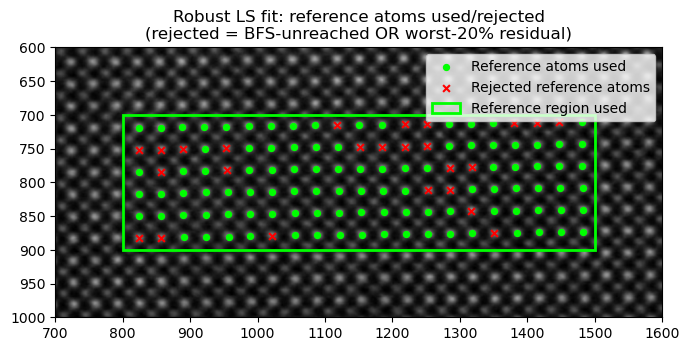

In [25]:
# ── METHOD 2 | Optional diagnostic: reference atoms rejected from LS fit ───
# Green = atoms used in final robust LS fit.
# Red = rejected, either because BFS could not connect them to the reference
# anchor through validated edges, or because they were in the worst-20% by
# residual among the atoms that were reached.

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(img, cmap='gray', origin='upper')

ax.scatter(ref_pos_m2[good_ref, 0], ref_pos_m2[good_ref, 1],
           s=18, c='lime', label='Reference atoms used')
ax.scatter(ref_pos_m2[~good_ref, 0], ref_pos_m2[~good_ref, 1],
           s=24, c='red', marker='x', label='Rejected reference atoms')

ref_rect = mpatches.Rectangle(
    (REF_X_MIN_EFF, REF_Y_MIN_EFF),
    REF_X_MAX_EFF - REF_X_MIN_EFF,
    REF_Y_MAX_EFF - REF_Y_MIN_EFF,
    linewidth=2,
    edgecolor='lime',
    facecolor='none',
    label='Reference region used'
)
ax.add_patch(ref_rect)

ax.set_xlim(REF_X_MIN_EFF - 100, REF_X_MAX_EFF + 100)
ax.set_ylim(REF_Y_MAX_EFF + 100, REF_Y_MIN_EFF - 100)
ax.set_aspect('equal')
ax.legend(loc='best')
ax.set_title('Robust LS fit: reference atoms used/rejected\n(rejected = BFS-unreached OR worst-20% residual)')
plt.tight_layout()
plt.show()

### Step 3 — Compute per-atom displacement vectors (diagnostic only)

The displacement vector **u**_i = r_measured,i − r_ideal,i quantifies how much each
atom has shifted from where it would sit in a perfect lattice extrapolated rigidly
from the reference region. Inside the reference region these values are near zero
by construction.

**Caveat**: because `r_ideal` is extrapolated as a single rigid lattice from a
small reference patch, even a tiny (sub-percent) mismatch between the fitted
reference vectors and the true local lattice elsewhere accumulates **linearly**
with distance from the reference region — so `|u|` can grow large far from the
reference patch even with no local strain anomaly at all. This is a diagnostic for
spotting gross outliers/defects, not the basis of the strain tensor: Step 4 below
does **not** use `u_disp_m2` or `ideal_pos_m2` — it computes strain purely from
each atom's own local neighbors, so it cannot inherit this long-range drift.
</cell>


Displacement magnitude inside valid rectangle (2314 / 2321 atoms reached by BFS, 7 excluded as unreached):
  mean: 6.311 px  (76.9 pm)
  max:  26.246 px  (319.9 pm)
  mean |u| in reference region: 0.590 px


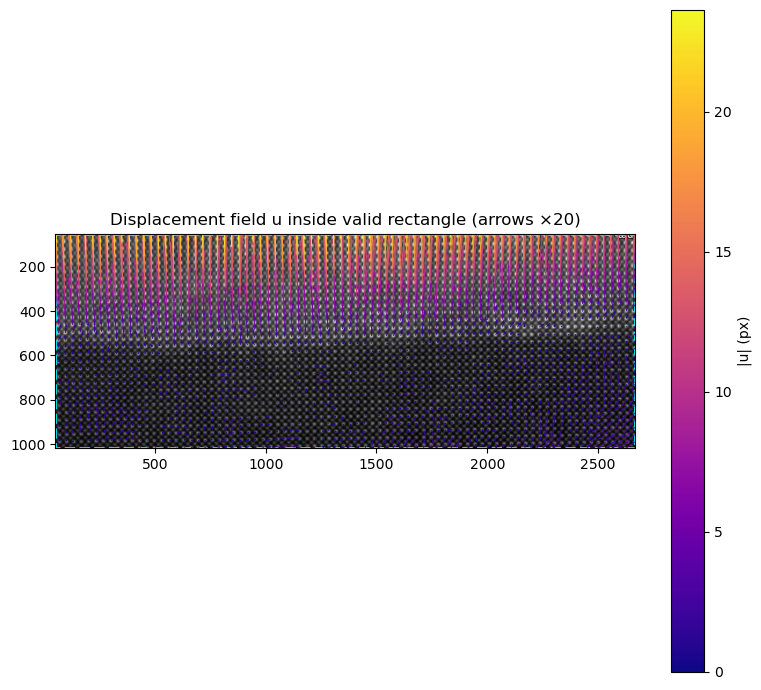

In [26]:
# ── METHOD 2 | Step 3: Displacement vectors u = measured − ideal ─────────
# Calculated only for valid atoms (margins excluded) that BFS could connect
# to the reference anchor; the small remainder stays NaN and is excluded from
# every statistic and plot below, instead of being silently extrapolated.

u_disp_m2 = pos_m2 - ideal_pos_m2          # (N_valid, 2), in pixels; NaN rows where unreached
u_disp_nm_m2 = u_disp_m2 * sampling        # (N_valid, 2), in nm

mag_m2 = np.linalg.norm(u_disp_m2, axis=1)   # NaN where unreached
n_unreached_m2 = int(np.sum(~bfs_visited_m2))

print(f'Displacement magnitude inside valid rectangle '
      f'({int(bfs_visited_m2.sum())} / {len(pos_m2)} atoms reached by BFS, '
      f'{n_unreached_m2} excluded as unreached):')
print(f'  mean: {np.nanmean(mag_m2):.3f} px  ({np.nanmean(mag_m2)*sampling*1000:.1f} pm)')
print(f'  max:  {np.nanmax(mag_m2):.3f} px  ({np.nanmax(mag_m2)*sampling*1000:.1f} pm)')
print(f'  mean |u| in reference region: {np.nanmean(mag_m2[ref_mask_m2]):.3f} px')

# Displacement vector field overlaid only inside the valid working rectangle
# (BFS-unreached atoms are simply omitted, not drawn with a bogus vector)
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(img, cmap='gray', origin='upper')

# Show valid rectangle
valid_rect = mpatches.Rectangle(
    (VALID_X_MIN, VALID_Y_MIN),
    VALID_X_MAX - VALID_X_MIN,
    VALID_Y_MAX - VALID_Y_MIN,
    linewidth=2,
    edgecolor='cyan',
    facecolor='none',
    linestyle='--'
)
ax.add_patch(valid_rect)

pos_m2_plot = pos_m2[bfs_visited_m2]
u_disp_m2_plot = u_disp_m2[bfs_visited_m2]
mag_m2_plot = mag_m2[bfs_visited_m2]

scale_factor = 20   # visual amplification; set to 1 for true scale
qv = ax.quiver(
    pos_m2_plot[:, 0], pos_m2_plot[:, 1],
    u_disp_m2_plot[:, 0] * scale_factor, u_disp_m2_plot[:, 1] * scale_factor,
    mag_m2_plot, cmap='plasma', scale=1, scale_units='xy', angles='xy',
    width=0.0015, headwidth=3, clim=(0, np.percentile(mag_m2_plot, 98))
)
plt.colorbar(qv, ax=ax, label='|u| (px)')
ax.set_title(f'Displacement field u inside valid rectangle (arrows ×{scale_factor})')
ax.set_xlim(VALID_X_MIN, VALID_X_MAX)
ax.set_ylim(VALID_Y_MAX, VALID_Y_MIN)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Step 4 — Per-atom local deformation gradient (strain AND rotation tensor)

**Why the previous grid-interpolation + finite-difference approach was replaced.**
The old pipeline built `u = r_measured − r_ideal` against a single rigid lattice
extrapolated from the reference patch (Step 3), then interpolated `u` onto a grid
and differentiated it with `np.gradient`. Two problems compound there:

1. **Long-range extrapolation bias.** `r_ideal` is built from `origin_fit`,
   `za0_fit`, `za1_fit` — vectors fitted from only the ~tens of atoms inside the
   small reference patch — and then applied rigidly across the *entire* image,
   atoms tens of unit cells away included. Even a sub-percent mismatch between
   `za0_fit`/`za1_fit` and the true local lattice elsewhere accumulates **linearly**
   with distance from the patch, so `|u|` (and therefore the strain computed from
   it) keeps growing far from the reference region even where there is no local
   strain at all. Rejecting bad reference atoms only improves the fit *at the
   patch* — it cannot fix this long-range drift.
2. **Differentiation noise amplification.** `np.gradient` finite-differencing a
   `griddata`-interpolated field built from sparse, noisy atomic positions
   amplifies any single bad atom or residual indexing slip into a large, spatially
   spiky strain artifact (the dark/bright "blobs" seen in earlier strain maps).

**The fix below removes both causes simultaneously** by computing the strain and
rotation tensor **per atom, from that atom's own local bonds only** — never from
an extrapolated absolute position, and never from differentiating an interpolated
field.

For atom *i*, take whichever of its (up to 4) `+za0`/`-za0`/`+za1`/`-za1`
neighbors survived the loop-closure validation (`neighbor_idx_clean`). Each gives
a *measured* bond vector **m**_d = `neighbor_vec[i, d]` and a *reference* bond
vector **e**_d (the corresponding Stage-B-fitted lattice vector: `za0_fit`,
`-za0_fit`, `za1_fit`, `-za1_fit`). The local 2×2 deformation gradient **F**_i is
the least-squares solution of

$$\mathbf{m}_d \approx F_i\, \mathbf{e}_d \quad \text{over all available directions } d$$

(this requires at least one `za0`-direction bond **and** one `za1`-direction bond
to be solvable). Strain and rotation then follow from the symmetric/antisymmetric
decomposition of **F**_i:

$$\varepsilon_i = \tfrac{1}{2}\left(F_i + F_i^\top\right) - I, \qquad
\omega_i = \tfrac{1}{2}\left(F_i - F_i^\top\right)$$

Because **F**_i only ever uses atom *i*'s own immediate, validated bonds, a bad
atom or a reference-fit bias can corrupt at most that single atom's tensor — it
has no mechanism to propagate via interpolation/differentiation to neighboring
atoms, and no accumulation with distance from the reference region. The per-atom
values are only interpolated onto a grid **afterwards**, purely for visualization
— the grid in Step 5 plays no role in the strain calculation itself.


In [27]:
# ── METHOD 2 | Step 4: Per-atom local deformation gradient → strain/rotation ─
# Computed directly from each atom's own validated bonds (neighbor_idx_clean /
# neighbor_vec, shared graph) against the Stage-B-fitted reference lattice
# vectors (za0_fit, za1_fit). No absolute/extrapolated position is used here,
# so this cannot inherit the long-range drift described in Step 3's caveat,
# and no grid differentiation is involved, so a single bad atom cannot smear
# into neighboring pixels.

ref_vec_for_dir = {0: za0_fit, 1: -za0_fit, 2: za1_fit, 3: -za1_fit}
za0_dirs, za1_dirs = (0, 1), (2, 3)

full_idx_m2 = np.where(valid_mask)[0]
n_atoms_m2 = len(pos_m2)

F_tensor = np.full((n_atoms_m2, 2, 2), np.nan)
n_dirs_used = np.zeros(n_atoms_m2, dtype=int)

for k in range(n_atoms_m2):
    i_full = full_idx_m2[k]
    E_rows, M_rows = [], []
    has_za0 = has_za1 = False
    for d in range(4):
        j = neighbor_idx_clean[i_full, d]
        if j < 0:
            continue
        E_rows.append(ref_vec_for_dir[d])
        M_rows.append(neighbor_vec[i_full, d])
        if d in za0_dirs:
            has_za0 = True
        if d in za1_dirs:
            has_za1 = True
    n_dirs_used[k] = len(E_rows)
    if not (has_za0 and has_za1):
        continue
    E = np.asarray(E_rows)
    M = np.asarray(M_rows)
    F_T, *_ = np.linalg.lstsq(E, M, rcond=None)   # solves E @ F^T ≈ M
    F_tensor[k] = F_T.T

valid_F = np.all(np.isfinite(F_tensor.reshape(n_atoms_m2, 4)), axis=1)
n_no_bonds = int(np.sum(n_dirs_used == 0))
n_insufficient = int(np.sum(~valid_F) - n_no_bonds)

I2 = np.eye(2)
exx_atom = np.full(n_atoms_m2, np.nan)
eyy_atom = np.full(n_atoms_m2, np.nan)
exy_atom = np.full(n_atoms_m2, np.nan)
omega_atom = np.full(n_atoms_m2, np.nan)

for k in np.where(valid_F)[0]:
    F = F_tensor[k]
    eps = 0.5 * (F + F.T) - I2
    om = 0.5 * (F - F.T)
    exx_atom[k] = eps[0, 0]
    eyy_atom[k] = eps[1, 1]
    exy_atom[k] = eps[0, 1]
    omega_atom[k] = om[1, 0]

print('Per-atom local deformation gradient inside valid rectangle:')
print(f'  atoms with a usable tensor (>=1 za0-bond AND >=1 za1-bond): '
      f'{int(valid_F.sum())} / {n_atoms_m2} ({100*valid_F.sum()/n_atoms_m2:.1f}%)')
print(f'  atoms with zero validated bonds at all: {n_no_bonds}')
print(f'  atoms with bonds but missing one whole axis (za0 or za1): {n_insufficient}')
print(f'  εxx: mean={np.nanmean(exx_atom)*100:+.2f}%   std={np.nanstd(exx_atom)*100:.2f}%')
print(f'  εyy: mean={np.nanmean(eyy_atom)*100:+.2f}%   std={np.nanstd(eyy_atom)*100:.2f}%')
print(f'  εxy: mean={np.nanmean(exy_atom)*100:+.2f}%   std={np.nanstd(exy_atom)*100:.2f}%')
print(f'  ωxy (rigid rotation): mean={np.nanmean(omega_atom)*100:+.2f}%   '
      f'std={np.nanstd(omega_atom)*100:.2f}%')
print('  (A nonzero mean ωxy with low spatial variation usually indicates a small')
print('   uniform specimen-tilt offset rather than a real structural feature; a')
print('   spatially-localized ωxy, e.g. at a boundary, is more likely physical.)')

# Grid interpolation of the per-atom tensor, for visualization ONLY (Step 5).
# This grid plays no role in computing exx_atom/eyy_atom/exy_atom/omega_atom
# above -- it is purely a smoothed view for plotting, unlike the old pipeline
# where the grid was the basis of the calculation itself.
cmap_strain = 'RdBu_r'
grid_step = 2   # px; controls visualization resolution only

xi = np.arange(VALID_X_MIN, VALID_X_MAX + 1, grid_step, dtype=float)
yi = np.arange(VALID_Y_MIN, VALID_Y_MAX + 1, grid_step, dtype=float)
Xi, Yi = np.meshgrid(xi, yi)

exx = griddata(pos_m2[valid_F], exx_atom[valid_F], (Xi, Yi), method='linear')
eyy = griddata(pos_m2[valid_F], eyy_atom[valid_F], (Xi, Yi), method='linear')
exy = griddata(pos_m2[valid_F], exy_atom[valid_F], (Xi, Yi), method='linear')
omega_xy = griddata(pos_m2[valid_F], omega_atom[valid_F], (Xi, Yi), method='linear')


Per-atom local deformation gradient inside valid rectangle:
  atoms with a usable tensor (>=1 za0-bond AND >=1 za1-bond): 2309 / 2321 (99.5%)
  atoms with zero validated bonds at all: 5
  atoms with bonds but missing one whole axis (za0 or za1): 7
  εxx: mean=-0.01%   std=1.02%
  εyy: mean=+2.63%   std=2.67%
  εxy: mean=+0.02%   std=0.62%
  ωxy (rigid rotation): mean=+0.13%   std=0.58%
  (A nonzero mean ωxy with low spatial variation usually indicates a small
   uniform specimen-tilt offset rather than a real structural feature; a
   spatially-localized ωxy, e.g. at a boundary, is more likely physical.)


### Step 4b — Atom-resolved scatter view (ground truth, before any smoothing)

The heatmaps in Step 5 are a `griddata` interpolation of the per-atom values
computed above, shown purely for visual clarity. Before trusting any feature in
those heatmaps, compare it against this **unsmoothed**, atom-by-atom scatter —
if a feature is real, it should already be visible here, atom by atom; if it only
appears after interpolation, it is an artifact of the smoothing/triangulation, not
of the measurement.


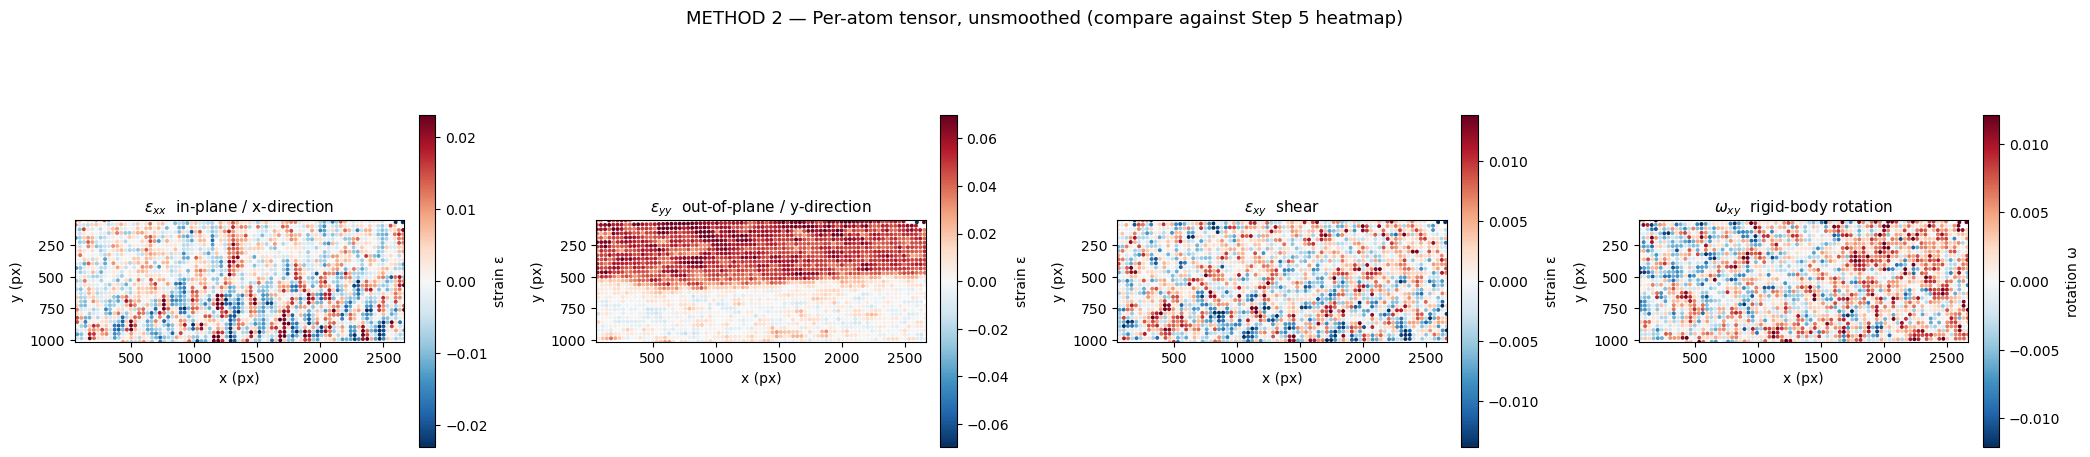

In [28]:
# ── METHOD 2 | Step 4b: Atom-resolved scatter of the per-atom tensor ───────
fig, axes = plt.subplots(1, 4, figsize=(21, 5))
labels_atom = [
    (r'$\varepsilon_{xx}$  in-plane / x-direction', exx_atom),
    (r'$\varepsilon_{yy}$  out-of-plane / y-direction', eyy_atom),
    (r'$\varepsilon_{xy}$  shear', exy_atom),
    (r'$\omega_{xy}$  rigid-body rotation', omega_atom),
]

for ax, (title, data) in zip(axes, labels_atom):
    finite = data[np.isfinite(data)]
    v = float(np.nanpercentile(np.abs(finite), 98)) if finite.size else 1.0
    sc = ax.scatter(pos_m2[:, 0], pos_m2[:, 1], c=data, s=8,
                     cmap=cmap_strain, vmin=-v, vmax=v, edgecolors='none')
    ax.set_xlim(VALID_X_MIN, VALID_X_MAX)
    ax.set_ylim(VALID_Y_MAX, VALID_Y_MIN)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('strain ε' if title.startswith(r'$\varepsilon') else 'rotation ω')

plt.suptitle('METHOD 2 — Per-atom tensor, unsmoothed (compare against Step 5 heatmap)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Step 5 — Visualise all strain tensor components (smoothed heatmap)

This view is a `griddata` interpolation of the robust per-atom tensor computed in
Step 4 — there is no differentiation here, only smoothing for display. Compare
against the unsmoothed atom-resolved scatter in Step 4b to check that any feature
you see is real and not an interpolation artifact.


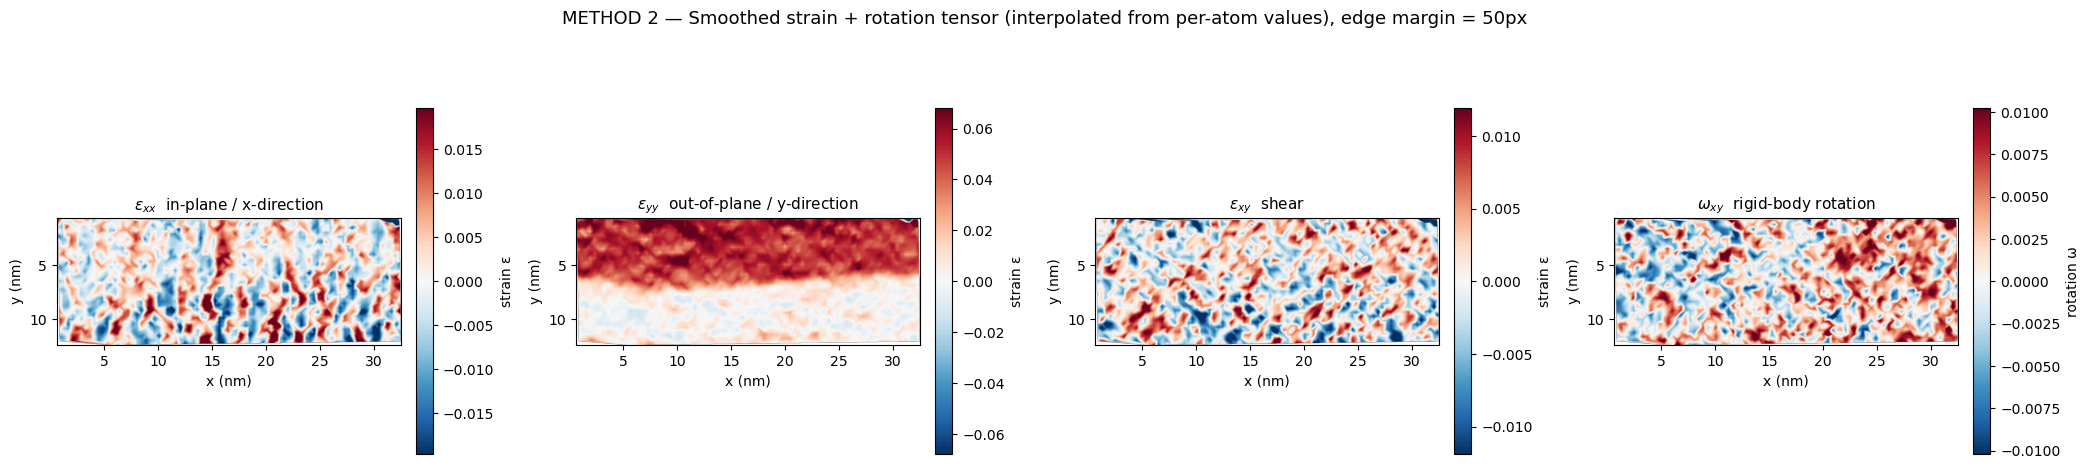

In [29]:
# ── METHOD 2 | Step 5: Full strain + rotation tensor maps inside valid rectangle ─
def sym_vlim(arr, pct=2):
    """Return symmetric (vmin, vmax) clipped at the given percentile."""
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return -1, 1
    v = float(np.nanpercentile(np.abs(finite), 100 - pct))
    return -v, v

# Extent of the cropped/valid calculation area in nm, but coordinates remain original-image based
extent_nm = [
    VALID_X_MIN * sampling,
    VALID_X_MAX * sampling,
    VALID_Y_MAX * sampling,
    VALID_Y_MIN * sampling,
]
cmap_strain = 'RdBu_r'

fig, axes = plt.subplots(1, 4, figsize=(21, 5))
labels = [
    (r'$\varepsilon_{xx}$  in-plane / x-direction', exx),
    (r'$\varepsilon_{yy}$  out-of-plane / y-direction', eyy),
    (r'$\varepsilon_{xy}$  shear', exy),
    (r'$\omega_{xy}$  rigid-body rotation', omega_xy),
]

for ax, (title, data) in zip(axes, labels):
    vn, vp = sym_vlim(data)
    im = ax.imshow(data, cmap=cmap_strain, vmin=vn, vmax=vp,
                   origin='upper', extent=extent_nm)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x (nm)')
    ax.set_ylabel('y (nm)')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('strain ε' if title.startswith(r'$\varepsilon') else 'rotation ω')

plt.suptitle(
    f'METHOD 2 — Smoothed strain + rotation tensor (interpolated from per-atom values), edge margin = {EDGE_MARGIN}px',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


### Step 6 — Side-by-side comparison: Method 1 vs Method 2 (out-of-plane)

Both methods measure out-of-plane strain (along za1).  
Method 1 uses a fixed external reference (d₀ bulk); Method 2 uses the chosen
internal reference region.  
Differences highlight regions where the calibration constant causes a global offset,
or where local shear redistributes strain differently between the two approaches.


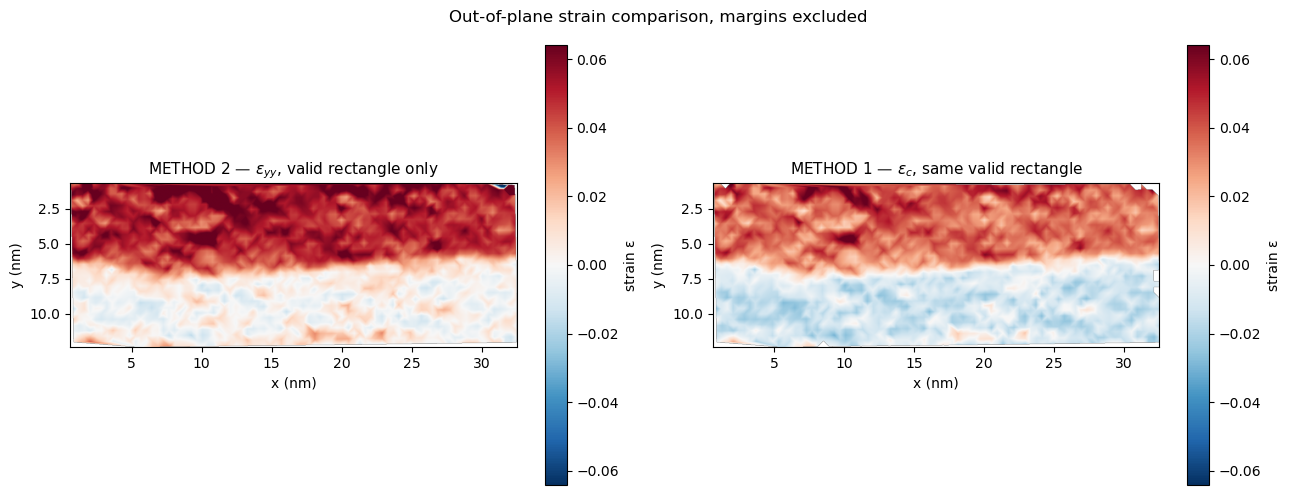

Out-of-plane strain summary inside valid rectangle:
  Method 2 (εyy):  mean=+2.75%  std=2.54%
  Method 1 (ε_c):  mean=+1.34%  std=2.44%
  Offset (M2−M1):  +1.40%  (reference-region dependent)


In [30]:
# ── METHOD 2 | Step 6: Comparison plot inside valid rectangle ─────────────
# Interpolate Method 1 strain onto the same valid-rectangle grid.

if 'eps_clean_m2' not in globals():
    raise NameError('eps_clean_m2 was not created because eps_clean was not available in Step 1A.')

eps_grid = griddata(pos_m2, eps_clean_m2, (Xi, Yi), method='linear')

# Use the same colour limits for both panels, ignoring NaNs
combined = np.concatenate([
    eyy[np.isfinite(eyy)].ravel(),
    eps_grid[np.isfinite(eps_grid)].ravel()
])
v_shared = float(np.nanpercentile(np.abs(combined), 98))
vn_s, vp_s = -v_shared, +v_shared

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(eyy, cmap=cmap_strain, vmin=vn_s, vmax=vp_s,
                     origin='upper', extent=extent_nm)
axes[0].set_title(r'METHOD 2 — $\varepsilon_{yy}$, valid rectangle only', fontsize=11)
axes[0].set_xlabel('x (nm)')
axes[0].set_ylabel('y (nm)')
plt.colorbar(im0, ax=axes[0], label='strain ε')

im1 = axes[1].imshow(eps_grid, cmap=cmap_strain, vmin=vn_s, vmax=vp_s,
                     origin='upper', extent=extent_nm)
axes[1].set_title(r'METHOD 1 — $\varepsilon_c$, same valid rectangle', fontsize=11)
axes[1].set_xlabel('x (nm)')
axes[1].set_ylabel('y (nm)')
plt.colorbar(im1, ax=axes[1], label='strain ε')

plt.suptitle('Out-of-plane strain comparison, margins excluded', fontsize=12)
plt.tight_layout()
plt.show()

# Numerical summary inside valid rectangle only
print('Out-of-plane strain summary inside valid rectangle:')
print(f'  Method 2 (εyy):  mean={np.nanmean(eyy)*100:+.2f}%  std={np.nanstd(eyy)*100:.2f}%')
print(f'  Method 1 (ε_c):  mean={np.nanmean(eps_grid)*100:+.2f}%  std={np.nanstd(eps_grid)*100:.2f}%')
delta = np.nanmean(eyy) - np.nanmean(eps_grid)
print(f'  Offset (M2−M1):  {delta*100:+.2f}%  (reference-region dependent)')

### Step 7 — Strain line profile across the image

A horizontal or vertical profile through the strain maps is a standard figure
in STEM strain-mapping articles.  It shows how strain evolves spatially
across an interface or layer sequence.  
Adjust `profile_axis` (`'x'` or `'y'`) and `profile_coord` (in nm) to place the cut.


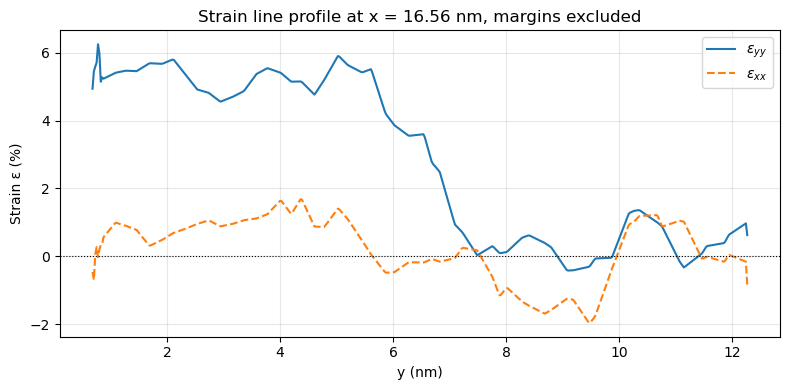

In [31]:
# ── METHOD 2 | Step 7: Strain line profile inside valid rectangle ─────────
profile_axis  = 'x'       # 'x' for a vertical cut, 'y' for a horizontal cut
profile_coord = 0.5 * (VALID_X_MIN + VALID_X_MAX) * sampling   # nm, centre of valid rectangle

if profile_axis == 'x':
    col_idx = int((profile_coord / sampling - VALID_X_MIN) / grid_step)
    col_idx = np.clip(col_idx, 0, eyy.shape[1] - 1)
    coord_nm = yi * sampling
    prof_eyy = eyy[:, col_idx]
    prof_exx = exx[:, col_idx]
    xlabel = 'y (nm)'
    cut_label = f'x = {profile_coord:.2f} nm'
else:
    row_idx = int((profile_coord / sampling - VALID_Y_MIN) / grid_step)
    row_idx = np.clip(row_idx, 0, eyy.shape[0] - 1)
    coord_nm = xi * sampling
    prof_eyy = eyy[row_idx, :]
    prof_exx = exx[row_idx, :]
    xlabel = 'x (nm)'
    cut_label = f'y = {profile_coord:.2f} nm'

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coord_nm, prof_eyy * 100, label=r'$\varepsilon_{yy}$')
ax.plot(coord_nm, prof_exx * 100, label=r'$\varepsilon_{xx}$', linestyle='--')
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel(xlabel)
ax.set_ylabel('Strain ε (%)')
ax.set_title(f'Strain line profile at {cut_label}, margins excluded')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()